In [1]:
# import modules
from PyCROSL.CRO_SL import *
from PyCROSL.AbsObjectiveFunc import *
from PyCROSL.SubstrateReal import *
from PyCROSL.SubstrateInt import *
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score

import pandas as pd
import numpy as np
import xarray as xr

from IPython.display import Image
from IPython.display import display

import warnings
warnings.filterwarnings('ignore')
import ipywidgets as widgets

import os
import sys
sys.path.insert(1, '../Modules/')
from EPE_optimisation_fast import optimisation_fast
from EPE_board_visualisation import *

# Outline

Once the target variables have been defined, a feature selection framework is applied to identify the most relevant associated drivers/predictors over the selected location. The framework used is the spatio-temporal cluster-optimised feature selection framework (STCO-FS). This is carried out through the following steps:

- Step 1: Open the dataset containing the target values for the location of interest.
- Step 2: Open the predictors dataset.
- Step 3: Introduce the basic concepts of the feature selection algorithm.
- Step 4: Run the feature selection algorithm.
- Step 5: Visualise the feature selection results.

Cells marked with the “->” symbol require user action.

# Step-1 - Open Target Dataset

-> Define the grid point, accumulation time and percentile threshold considered in the previous notebook.

In [2]:
### TODO ###
region="Cluj-Napoca"
accumulation_time = 3
quantile = 0.90

Open the target time series NQp generated in the previous notebook for the overlapping seasons.

In [3]:
# read the csv file
target_dataset = pd.read_csv(f"Output/N{int(quantile*100)}p_{region}_ac{accumulation_time}.csv", index_col='pred_date')

# Step-2 - Load and check predictor data

This framework starts from the definition of a pool of potential predictors, i.e. variables selected to represent atmospheric and oceanic conditions known to influence the European climate.

To reduce their spatial dimensionality, a clustering procedure is applied to these potential predictors. This has already been performed using an enhanced version of the k-means clustering algorithm based on a weighted multi-dimensional distance metric.

Once the clusters have been identified, the area-weighted spatial average weekly time series is computed for each cluster.

In [4]:
# open the predictors data
pred_dataframe = pd.read_csv('../DATA/Predictors_dataset_ERA5_weekly_1940_2024_kmean_1993_2016_0.05_clim_1993_2016_pcs_0.01_centroids_id5_AMJ.csv', index_col=0)

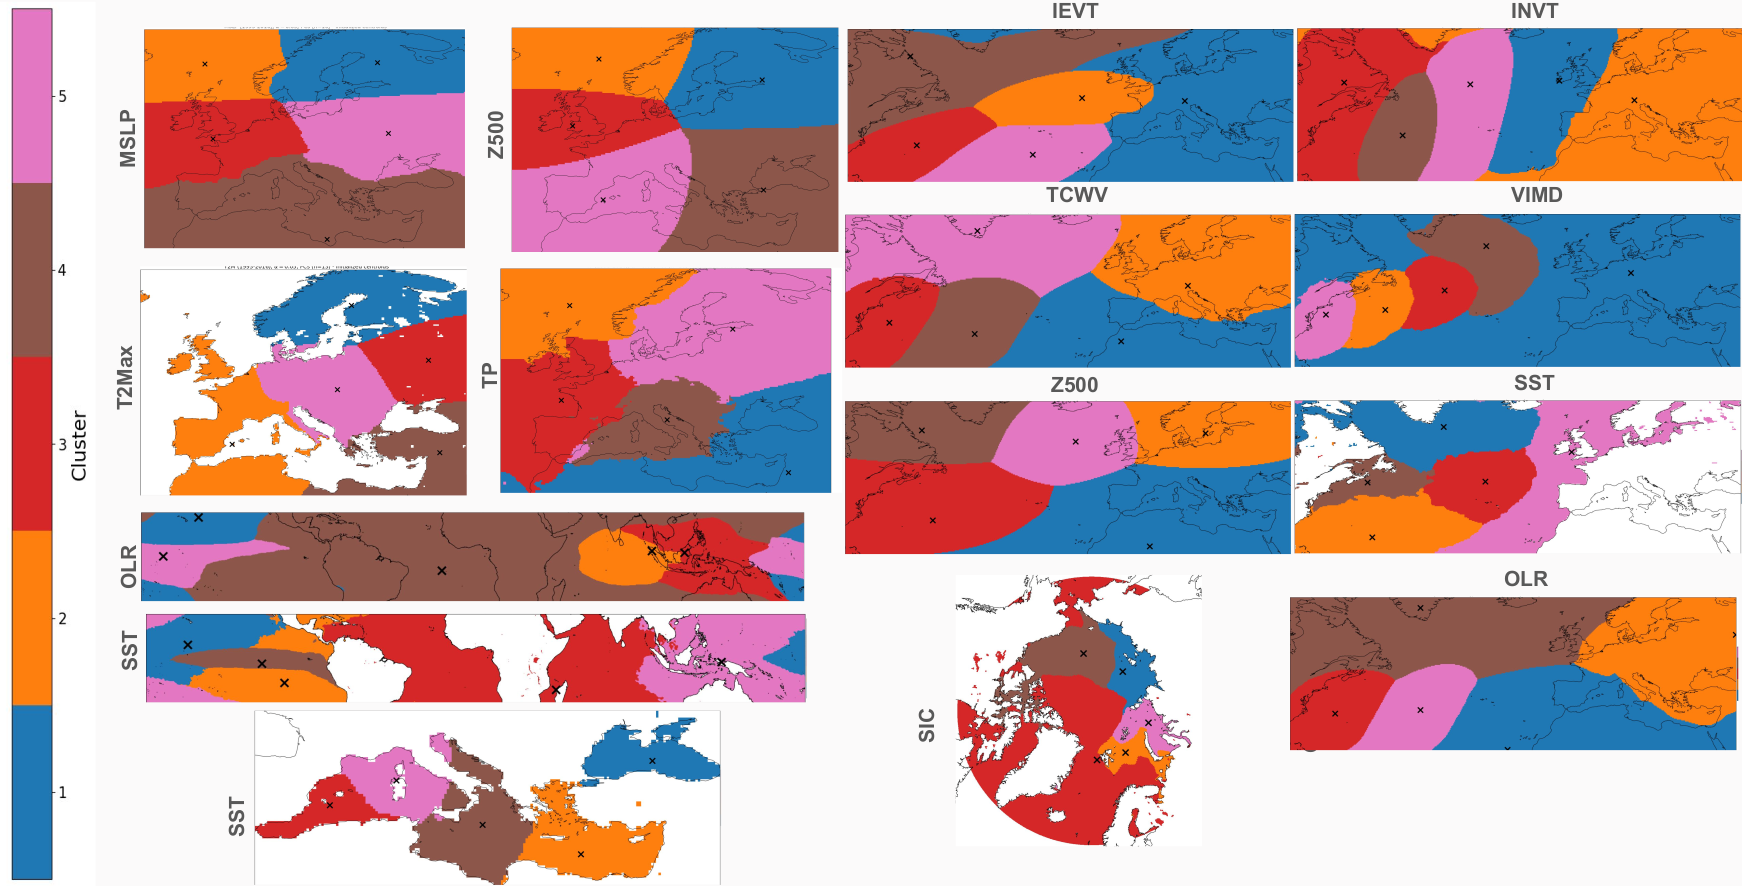

In [5]:
display(Image(filename='../clusters_5.png'))

Inspect the predictor dataset.

In [6]:
pred_dataframe

,SIC_ARC_cluster1,SIC_ARC_cluster2,SIC_ARC_cluster3,SIC_ARC_cluster4,SIC_ARC_cluster5,SST_TR_cluster1,SST_TR_cluster2,SST_TR_cluster3,SST_TR_cluster4,SST_TR_cluster5,...,INVT_NA_cluster2,INVT_NA_cluster3,INVT_NA_cluster4,INVT_NA_cluster5,IEVT_NA_cluster1,IEVT_NA_cluster2,IEVT_NA_cluster3,IEVT_NA_cluster4,IEVT_NA_cluster5,weekofyear
1940-01-06,0.012207,0.292840,0.054743,0.015510,0.073226,0.125552,0.143836,-0.123671,0.690666,-0.541840,...,1.364121,-30.663690,-42.484104,6.830822,15.667413,-80.818526,102.139114,-48.361754,213.475139,1
1940-01-13,0.013360,0.302383,0.057563,0.016312,0.064358,0.192031,0.311188,-0.015554,0.753973,-0.527952,...,-14.743094,-35.300894,-91.249523,65.405294,-25.773304,-110.390156,-45.799117,-12.163651,80.614943,2
1940-01-20,0.014969,0.305140,0.057460,0.015895,0.056064,0.188972,0.352944,-0.000205,0.764714,-0.517203,...,8.358948,1.054856,-32.607902,-24.762641,-5.730902,-121.716379,-5.037300,-66.458475,6.725991,3
1940-01-27,0.017942,0.305929,0.052604,0.016321,0.054155,0.206112,0.279598,-0.030624,0.800102,-0.512787,...,5.103179,-18.653815,-11.446472,26.705503,-27.092530,4.842914,71.227759,-49.063263,137.480535,4
1940-02-03,0.019612,0.308392,0.049056,0.016816,0.052496,0.285993,0.174773,-0.042499,0.876578,-0.516095,...,2.160187,-52.383256,-36.630352,4.834982,1.752664,14.137570,11.157263,-60.925816,203.756510,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-01,-0.002487,-0.262437,-0.040427,0.030881,-0.071600,0.120229,0.047430,0.555843,-0.308855,0.580849,...,-7.021814,-0.739555,9.778362,-51.019118,-0.318273,31.515980,132.713076,-54.090234,120.998236,48
2024-12-08,0.013740,-0.253295,-0.029495,0.034159,-0.053105,0.128919,-0.068774,0.462802,-0.391419,0.598042,...,-5.399630,-25.472890,105.776828,75.718235,-9.809219,89.272681,70.402353,-6.041766,-71.470520,49
2024-12-15,0.019983,-0.223614,-0.042371,0.007799,0.004195,0.088664,-0.170781,0.398743,-0.446929,0.605858,...,-9.194914,25.439182,5.140636,-45.364837,-4.885000,-129.816785,-132.012701,59.904861,-137.666436,50
2024-12-22,0.020619,-0.157007,-0.029643,0.013242,0.031308,0.062908,-0.170214,0.337308,-0.540156,0.622143,...,-20.319424,13.216588,17.822397,19.527330,24.234377,26.058944,-93.777893,48.919042,-75.428709,51


In [7]:
# check the names of the potential predictors
print ("List of Potential Predictors")
print (pred_dataframe.columns.values)
column_names = pred_dataframe.columns.tolist()

List of Potential Predictors
['SIC_ARC_cluster1' 'SIC_ARC_cluster2' 'SIC_ARC_cluster3'
 'SIC_ARC_cluster4' 'SIC_ARC_cluster5' 'SST_TR_cluster1' 'SST_TR_cluster2'
 'SST_TR_cluster3' 'SST_TR_cluster4' 'SST_TR_cluster5' 'SST_EU_cluster1'
 'SST_EU_cluster2' 'SST_EU_cluster3' 'SST_EU_cluster4' 'SST_EU_cluster5'
 'TP_EU_cluster1' 'TP_EU_cluster2' 'TP_EU_cluster3' 'TP_EU_cluster4'
 'TP_EU_cluster5' 'T2M_EU_cluster1' 'T2M_EU_cluster2' 'T2M_EU_cluster3'
 'T2M_EU_cluster4' 'T2M_EU_cluster5' 'Z500_EU_cluster1' 'Z500_EU_cluster2'
 'Z500_EU_cluster3' 'Z500_EU_cluster4' 'Z500_EU_cluster5'
 'MSLP_EU_cluster1' 'MSLP_EU_cluster2' 'MSLP_EU_cluster3'
 'MSLP_EU_cluster4' 'MSLP_EU_cluster5' 'OLR_TR_cluster1' 'OLR_TR_cluster2'
 'OLR_TR_cluster3' 'OLR_TR_cluster4' 'OLR_TR_cluster5' 'OLR_NA_cluster1'
 'OLR_NA_cluster2' 'OLR_NA_cluster3' 'OLR_NA_cluster4' 'OLR_NA_cluster5'
 'SST_NA_cluster1' 'SST_NA_cluster2' 'SST_NA_cluster3' 'SST_NA_cluster4'
 'SST_NA_cluster5' 'Z500_NA_cluster1' 'Z500_NA_cluster2'
 'Z500_NA

Visualise the weekly time series of a predictor for a specific year. The lag-0 day is also indicated; this corresponds to the beginning of the season over which the target value NQp is predicted. In this case, the target season is AMJ (April–May–June).

The forecast is considered seasonal because the target data correspond to the April–May–June period, while the predictor data are derived from the months preceding April.

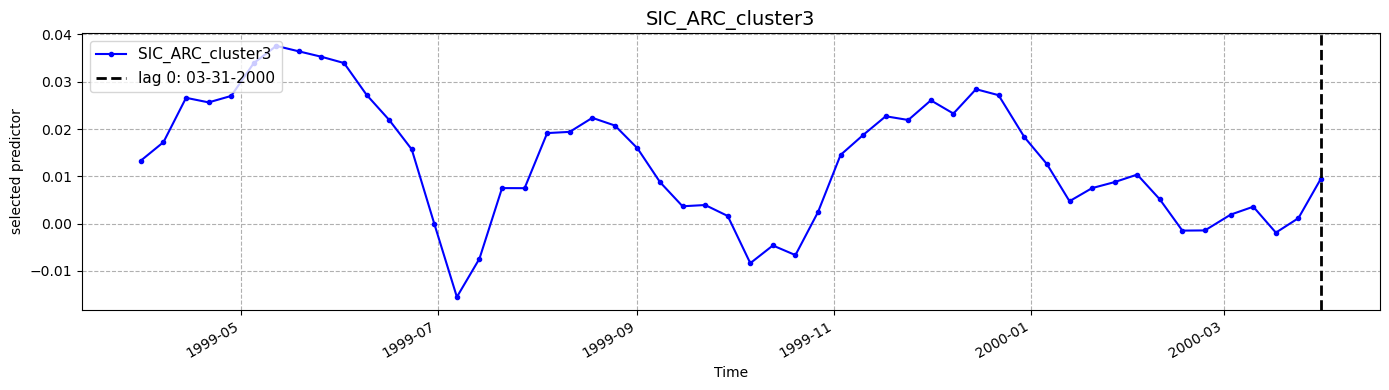

In [8]:
# select the cluster to visualise
show_cluster="SIC_ARC_cluster3"

# plot the time series
fig, ax = plt.subplots(figsize=(14,4))

year=2000

# timeseries in mm/day
ts = pred_dataframe[show_cluster].loc['1999-03-31':'2000-03-31']
ts.index = pd.to_datetime(ts.index)

# plot daily timeseries
ts.plot(ax=ax, color='blue', linewidth=1.5, ls='-', marker='.')

title = f"{ts.name}"
ax.axvline(ts.index[-1], color='k', linestyle='--', linewidth=2, label = f'lag 0: 03-31-2000')
ax.set_title(title, fontsize=14)

# labels, grid, legend
ax.set_ylabel('selected predictor')
ax.set_xlabel('Time')
ax.grid(ls='--')
ax.legend(loc='upper left', fontsize=11)


plt.tight_layout()
plt.show()

# Step-3 - Basic concept of feature selection algorithm

Once the potential predictor time series have been defined, the actual feature selection can be performed. Notably, this framework is able to identify not only whether a specific cluster variable is a relevant driver for the target variable, but also the associated time lag and sequence length.

-> To better understand the output of the feature selection process, modify the configuration below and inspect the resulting plot in order to familiarise yourself with these concepts.

In [9]:
# select the lag time to visualise
final_sequence_widget = widgets.IntSlider(
    value=5,                    # Default value
    min=0,                      # Minimum duration
    max=20,                     # Maximum duration  
    step=1,                     # Step size
    description='Lag time (weeks):',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='400px')
)

final_sequence_widget

IntSlider(value=5, description='Lag time (weeks):', layout=Layout(width='400px'), max=20, style=SliderStyle(de…

In [10]:
# select the sequence length to visualise
sequence_length_widget = widgets.IntSlider(
    value=2,                    # Default value
    min=0,                      # Minimum duration
    max=8,                     # Maximum duration  
    step=1,                     # Step size
    description='Sequence length (weeks):',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='400px')
)

sequence_length_widget

IntSlider(value=2, description='Sequence length (weeks):', layout=Layout(width='400px'), max=8, style=SliderSt…

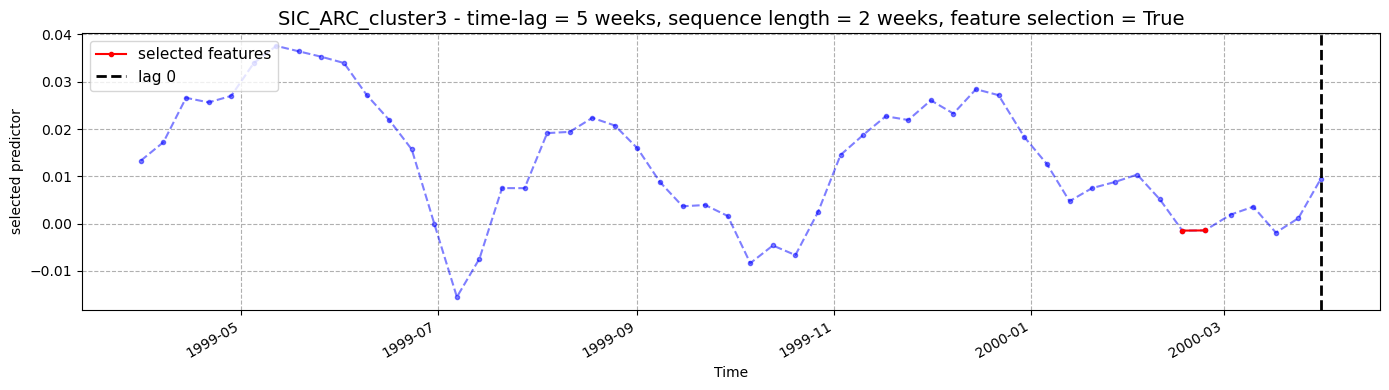

In [11]:
# example of possible configuration
sequence_length_ex = sequence_length_widget.value
final_sequence_ex =final_sequence_widget.value
feat_sel_ex = np.where(sequence_length_ex == 0, 0, 1) # 0 or 1 # feature selction

# plot the time series
fig, ax = plt.subplots(figsize=(14,4))

# plot daily timeseries
ts.plot(ax=ax, color='blue', linewidth=1.5, ls='--', marker='.', alpha= 0.5, label='')

if feat_sel_ex == 1:
    ts_selected = ts.iloc[-final_sequence_ex-sequence_length_ex:-final_sequence_ex]
    ts_selected.plot(ax=ax, color='red', linewidth=1.5, ls='-', marker='.', label='selected features')


ax.axvline(ts.index[-1], color='k', linestyle='--', linewidth=2, label = f'lag 0')

title = f"{ts.name} - time-lag = {final_sequence_ex} weeks, sequence length = {sequence_length_ex} weeks, feature selection = {str(feat_sel_ex==1)}"
ax.set_title(title, fontsize=14)



# labels, grid, legend
ax.set_ylabel('selected predictor')
ax.set_xlabel('Time')
ax.grid(ls='--')
ax.legend(loc='upper left', fontsize=11)


plt.tight_layout()
plt.show()

# Step-4 - Feature selection

The feature selection is performed using the Probabilistic Coral Reef Optimisation algorithm with Substrate Layers (PCRO-SL).

In simple terms, the algorithm evaluates multiple combinations of variable clusters, time lag, and sequence length. Each combination is assigned a skill score that quantifies the forecast error of a linear regression model trained on that configuration of predictors. This score is computed only on the training period (1941-2009) using a 5-fold cross-validation.

The skill score used is the normalised root-mean-squared error (nRMSE), where the RMSE is normalised by the standard deviation of the target dataset. A lower nRMSE indicates better predictive performance.

The optimisation algorithm begins with a random initial guess of the parameter combinations, then iteratively improves them using different search strategies. After thousands of evaluations, it converges towards an optimal combination that minimises the skill score.

The dataset is split into training and test sets. 

In [12]:
# define the training and test set
first_train = "1941-03-17"
last_train = "2010-03-17" 
first_test = last_train
last_test = "2024-04-14"


# define the train index
first_train_index=int(np.argwhere(target_dataset.index==first_train))
last_train_index=int(np.argwhere(target_dataset.index==last_train))

-> Define the number of feature selection algorithm evaluations to run.

In [13]:
eval_widget = widgets.IntSlider(
    value=2000,                    # Default value
    min=1000,                      # Minimum duration
    max=10000,                     # Maximum duration  
    step=100,                     # Step size
    description='Number of Evaluations:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='400px')
)

eval_widget

IntSlider(value=2000, description='Number of Evaluations:', layout=Layout(width='400px'), max=10000, min=1000,…

In [14]:
# check the values
num_eval=eval_widget.value
print ("Number of evaluations to run: ",num_eval)

Number of evaluations to run:  2000


Run the feature selection algorithm.

In [15]:
# define the file names
indiv_file = f'Output/optimisation_output_{region}_N{int(quantile*100)}p_neval{num_eval}_ac{accumulation_time}_fast.csv'
solution_file = f'Output/optimisation_output_{region}_N{int(quantile*100)}p_neval{num_eval}_ac{accumulation_time}_fast_sol.csv'

computed_config = os.path.exists(solution_file)

# check the if the feature selection has been already computed for this evaluation
if computed_config:
    print('Configuration already computed.')
    sol_data = pd.read_csv(indiv_file, index_col=None, sep=' ', header=0)  
else:
    sol_data = pd.DataFrame(columns=['CV', 'Test', 'Sol'])
    sol_data.to_csv(indiv_file, sep=' ', header=sol_data.columns, index=None)

In [16]:
# Useful quantities

# LAG and WINDOW
MAX_LAG = 26
MAX_WINDOW = 8
MAX_SHIFT = MAX_LAG + MAX_WINDOW
NLEN = len(pred_dataframe)
idx_pred = pred_dataframe.index[MAX_SHIFT:]
valid_idx = idx_pred.intersection(target_dataset.index) # Valid indices

X_blocks = []
col_meta = []
col_index = {} # To identify lags
col_id = 0
for var_i, col in enumerate(pred_dataframe.columns):
    s = pred_dataframe[col].to_numpy()
    for lag in range(1, MAX_SHIFT + 1):
        xlag = s[MAX_SHIFT - lag : NLEN - lag]
        X_blocks.append(xlag.reshape(-1, 1))
        col_meta.append((var_i, lag))
        col_index[(var_i, lag)] = col_id 
        col_id += 1

X_full = np.hstack(X_blocks).astype(np.float32)
pos = idx_pred.get_indexer(valid_idx)
X_full = X_full[pos, :]

y_full = target_dataset.reindex(valid_idx)['Target'].to_numpy()

X_train_full = X_full[first_train_index:last_train_index]
X_test_full  = X_full[last_train_index:]
y_train_full = y_full[first_train_index:last_train_index]
y_test_full  = y_full[last_train_index:]

# Avoiding standardization per generation
mu = X_train_full.mean(axis=0)
sigma = X_train_full.std(axis=0)
sigma[sigma == 0] = 1

# Cache to avoid computing repeated solutions
fitness_cache = {}

In [17]:
# Initialize the objective function with size = 3 * number of predictors
objfunc = optimisation_fast(
    size=3*pred_dataframe.shape[1], pred_dataframe=pred_dataframe,
    MAX_LAG=MAX_LAG, MAX_WINDOW=MAX_WINDOW,
    fitness_cache=fitness_cache, col_index=col_index, X_train_full=X_train_full,
    y_train_full=y_train_full, X_test_full=X_test_full, y_test_full=y_test_full, mu=mu, sigma=sigma, indiv_file=indiv_file
)

# Define CRO-SL parameters
params = {
    "popSize": 100,
    "rho": 0.6,
    "Fb": 0.98,
    "Fd": 0.2,
    "Pd": 0.8,
    "k": 3,
    "K": 20,
    "group_subs": True,

    "stop_cond": "Neval",
    "time_limit": 4000.0,
    "Ngen": 10000,
    "Neval": num_eval,
    "fit_target": 1000, 

    "verbose": True,
    "v_timer": 1,
    "Njobs": 1,

    "dynamic": True,
    "dyn_method": "success",
    "dyn_metric": "avg",
    "dyn_steps": 10,
    "prob_amp": 0.01,

    "prob_file": f"prob_history_N{int(quantile*100)}p_{region}_ac{accumulation_time}.csv",
    "popul_file": f"last_populationN{int(quantile*100)}p_{region}_ac{accumulation_time}.csv",
    "history_file": f"fit_history_N{int(quantile*100)}p_{region}_ac{accumulation_time}.csv",
    "solution_file": f"best_solution_N{int(quantile*100)}p_{region}_ac{accumulation_time}.csv",
    "indiv_file": f"indiv_hisotry_N{int(quantile*100)}p_{region}_ac{accumulation_time}.csv",
}

# Define operators for the algorithm
operators = [
    SubstrateInt("BLXalpha", {"F": 0.8}),
    SubstrateInt("Multipoint"),
    SubstrateInt("HS", {"F": 0.7, "Cr": 0.8, "Par": 0.2}),
    SubstrateInt("Xor"),
]

In [18]:
if not computed_config:
    # Initialize and run the optimization algorithm
    cro_alg = CRO_SL(objfunc, operators, params)
    solution, obj_value = cro_alg.optimize()#save_data = False, update_data = False
    # It prints the score for the training set (left) and the test set (rightCompute the number of days with accumulation exceeding the selected quantile.)
    
    # Save final solution
    solution.tofile(solution_file, sep=',')
    print(f"Optimization completed. Best objective value: {obj_value}")
    print(f"Solution saved to {solution_file}")

Starting optimization of Some Function
--------------------------------------

2.45248819514545 1.426314747123423
1.7248672829595946 1.2461941004213002
2.604711414780012 1.659934344865419
2.92965352448181 1.437223817087233
13.41805076250759 2.5337298760138665
3.2932877848707762 1.4971981308529991
2.53244907470935 1.3270302398874931
2.8220589013520723 1.954031375468121
3.566700934105012 2.498256776570146
3.4120628523275927 2.0476230434093736
3.2408030295562242 1.8336603625305834
2.0955572510841494 2.0844160127899647
3.6203345014002304 1.9540842752870065
3.2113278889610806 1.9868196388726986
3.3219006845074346 1.4552524673224392
2.3663175611671305 1.4103817580868938
2.4137057367409054 1.3922597085566384
3.3185523181163132 2.035385164980636
2.398030942373164 1.7006662623704853
3.0380317857287844 1.5643249077542485
2.6061699904286604 1.5631470494359074
1.7747996590297408 1.3441384584079588
3.094292426504663 1.548251785380304
2.282681442806879 1.8660096349836923
3.2857853224331266 2.0968056

# Step-5 - Visualisation

Inspect the feature selection results in terms of nRMSE for both the training and test sets.

In [19]:
print ("Training Score (CV - cross-validation) , Test Score , Solution array")

name = indiv_file
sol_file_av = pd.read_csv(name, index_col=None, sep=' ', header=0)    
num_sims=sol_file_av.shape[0]

print (sol_file_av)

print ("Number of optimisation evaluations: ", sol_file_av.shape[0])

Training Score (CV - cross-validation) , Test Score , Solution array
             CV      Test                                                Sol
0      2.452488  1.426315  [7 7 4 1 1 5 6 4 2 4 7 7 7 6 4 3 5 1 2 1 2 6 1...
1      1.724867  1.246194  [2 2 4 7 2 4 6 1 3 1 2 7 2 1 4 4 2 1 3 1 6 2 5...
2      2.604711  1.659934  [5 6 3 1 5 4 2 3 5 5 3 4 5 5 2 7 2 2 1 4 3 6 1...
3      2.929654  1.437224  [6 2 3 4 1 4 7 3 5 6 3 7 7 2 4 1 2 3 1 1 5 6 5...
4     13.418051  2.533730  [6 1 7 5 3 1 6 1 7 6 4 5 1 5 5 7 1 7 5 7 5 5 6...
...         ...       ...                                                ...
1955   1.293172  1.013512  [ 2  1  4  4  3  3  3  3  8  6  4  2  2  2  4 ...
1956   1.290762  1.068741  [ 2  4  4  3  2  2  2  3  3  5  3  2  2  1  5 ...
1957   1.105190  0.947866  [ 2  4  5  3  4  2  3  2  2  3  3  4  3  2  6 ...
1958   1.237388  1.016813  [ 1  1  4  3  2  3  3  3  4  6  3  2  3  1  6 ...
1959   2.159113  1.450460  [1 1 4 3 7 1 1 6 5 3 3 1 6 3 7 1 7 2 3 1 5 2 6...

[1960 

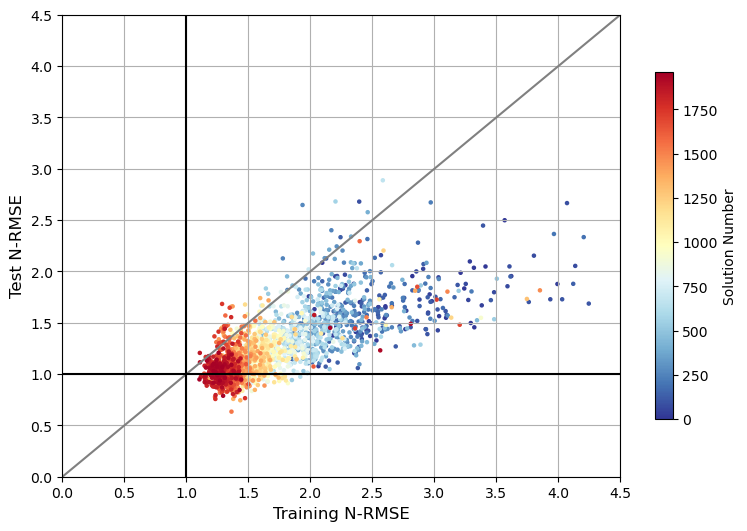

In [20]:
# Plot scatter plot to identify overfitting
scores_data_no_duplicates = sol_file_av.drop_duplicates().reset_index(drop=True)

plt.figure(figsize=(9,6))
plt.scatter(scores_data_no_duplicates['CV'],scores_data_no_duplicates['Test'],c=range(len(scores_data_no_duplicates)),s=5,alpha=1,cmap='RdYlBu_r')

cbar=plt.colorbar(label="Solution Number",shrink=0.75)
cbar.ax.tick_params(labelsize=10)

plt.plot([0,4.5],[0,4.5],ls='-', color='grey')
plt.axhline(y=1,ls='-',lw=1.5,color='black')
plt.axvline(x=1,ls='-',lw=1.5,color='black')

plt.xlabel("Training N-RMSE",fontsize=12)
plt.ylabel("Test N-RMSE",fontsize=12)
plt.xlim([0,4.5])
plt.ylim([0,4.5])

plt.grid()
#plt.savefig(path+'figures/opt_progress_2_{}_{}_at{}_{}{}.png'.format(region, period, accumulation_time, num_eval, sel_iter))
plt.show()

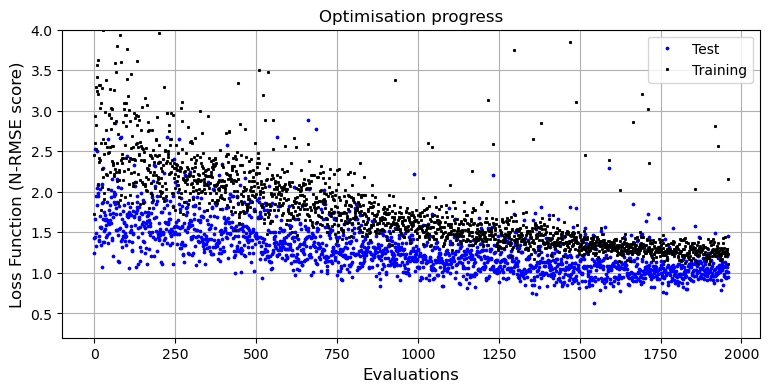

In [21]:
# Plot loss functions during evaluation process 
plt.figure(figsize=(9,4))

plt.plot(scores_data_no_duplicates.index,scores_data_no_duplicates['Test'],'b',marker='o',ms=1.7,lw=0, label = 'Test')
plt.plot(scores_data_no_duplicates.index,scores_data_no_duplicates['CV'],'k',marker='x',ms=1.7,lw=0, label = 'Training')

plt.title("Optimisation progress")
plt.xlabel('Evaluations',fontsize=12)

plt.ylabel('Loss Function (N-RMSE score)',fontsize=12)
plt.ylim([0.2,4])
plt.legend()
plt.grid()

plt.show()

Visualise the optimal combination of cluster variables, time lag, and sequence length. Black boxes indicate the values selected by the feature selection algorithm.

In [22]:
# extract the values of lag_time, sequence_length and feature_selection
array_best = np.fromstring(sol_file_av.Sol[sol_file_av.sort_values(by=['CV'],ascending=True).index[0]].replace('[', '').replace(']', '').replace('\n', ''), dtype=float, sep=' ')
split=int(array_best.shape[0]/3)

sequence_length_best = array_best[0:split]
final_sequence_best = array_best[split:split*2]
feat_sel_best = array_best[split*2:]

In [23]:
# create the board
n_rows = int((sequence_length_best + final_sequence_best).max())+10
n_cols = pred_dataframe.shape[1]
board_best = create_board(n_rows, n_cols, final_sequence_best, sequence_length_best, feat_sel_best)

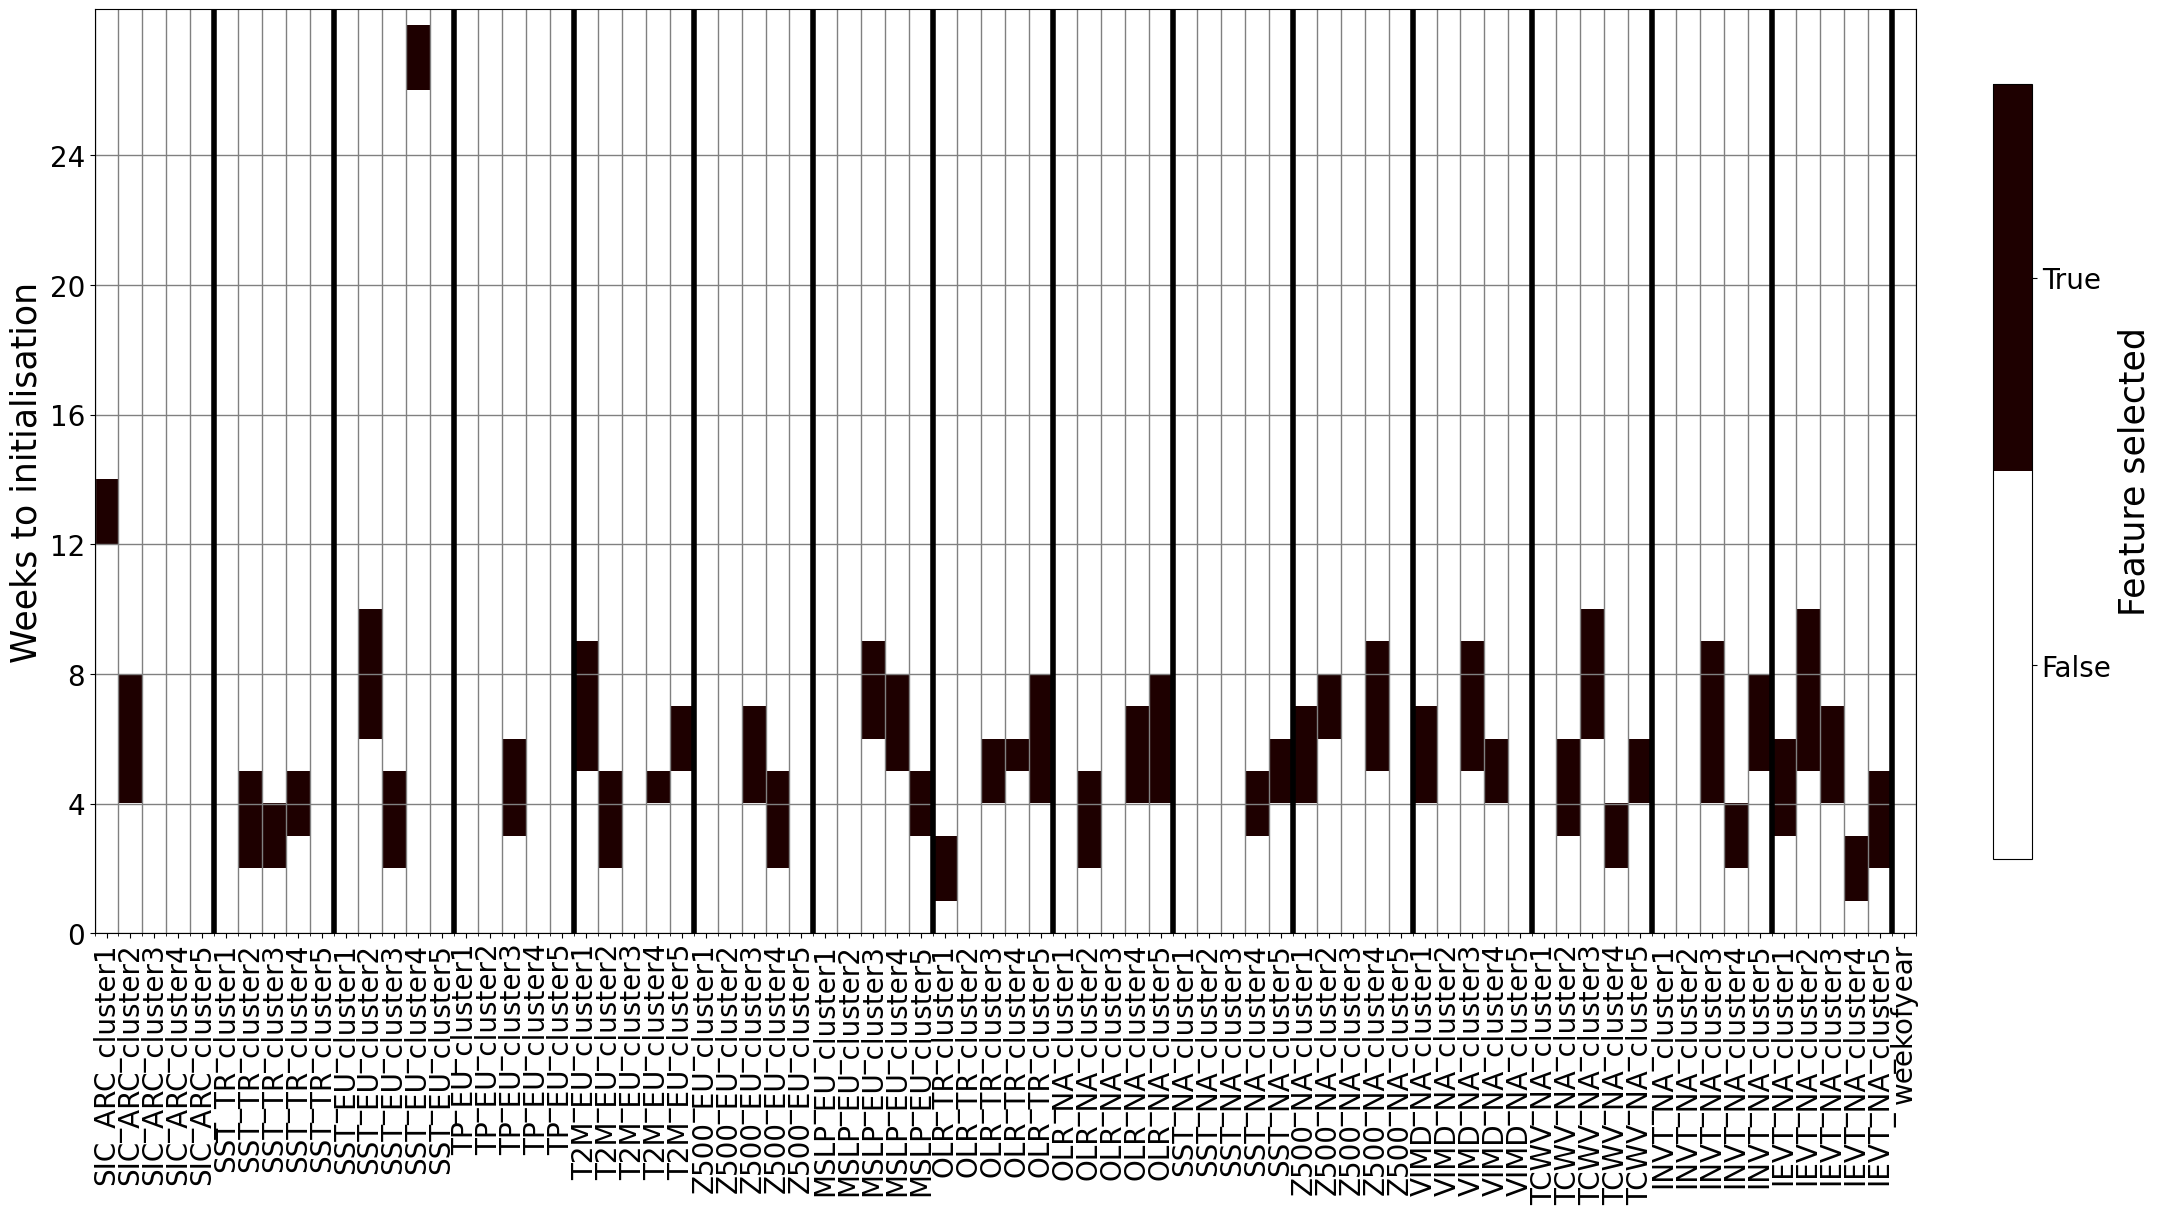

In [24]:
# plot
plot_board(board_best, column_names,True)

In [25]:
#display(Image(filename='../clusters_15.png'))